In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../../data/dataset_selection.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants — supprimés.")
df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

In [2]:
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad); x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [3]:
# -------------------------
# 2) Encoder les labels + split (identique aux autres notebooks)
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)
test_df, val_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row["y"])

train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)
test_ds  = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 6236 | Val : 780 | Test : 780


In [4]:
# -------------------------
# 3) Modèle ConvNeXt-Tiny
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

Device: cuda


In [5]:
# -------------------------
# 4) Fonctions train / eval
# -------------------------
def evaluate(m, loader):
    m.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = m(x)
            running_loss += criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

def train_one_epoch(m, loader):
    m.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = m(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

In [6]:
# -------------------------
# 5) Phase 1 : entraînement normal avec ReduceLROnPlateau
# On s'arrête quand la val acc se stabilise (patience=5)
# puis on passe en mode SWA
# -------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)

SWA_START_EPOCH = 20  # SWA commence après cette epoch
best_val_acc = 0.0
best_model_path = "convnext_tiny_swa.pth"

print("=== Phase 1 : entraînement normal ===")
for epoch in range(1, SWA_START_EPOCH + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)
    scheduler.step(va_acc)
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), best_model_path)
    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | lr {lr:.2e}")

print(f"\nFin phase 1 — meilleure val acc : {best_val_acc:.4f}")

=== Phase 1 : entraînement normal ===
Epoch 01 | train 0.7649/0.7619 | val 0.7058/0.8026 | lr 1.00e-04
Epoch 02 | train 0.6311/0.8364 | val 0.6422/0.8269 | lr 1.00e-04
Epoch 03 | train 0.5834/0.8663 | val 0.6177/0.8385 | lr 1.00e-04
Epoch 04 | train 0.5489/0.8823 | val 0.6633/0.8205 | lr 1.00e-04
Epoch 05 | train 0.5209/0.9033 | val 0.6278/0.8538 | lr 1.00e-04
Epoch 06 | train 0.4996/0.9200 | val 0.6192/0.8526 | lr 1.00e-04
Epoch 07 | train 0.4774/0.9277 | val 0.6119/0.8359 | lr 1.00e-04
Epoch 08 | train 0.4662/0.9408 | val 0.6189/0.8321 | lr 1.00e-04
Epoch 09 | train 0.4534/0.9444 | val 0.6443/0.8500 | lr 5.00e-05
Epoch 10 | train 0.4117/0.9703 | val 0.6358/0.8615 | lr 5.00e-05
Epoch 11 | train 0.3986/0.9785 | val 0.6349/0.8603 | lr 5.00e-05
Epoch 12 | train 0.3990/0.9751 | val 0.6291/0.8705 | lr 5.00e-05
Epoch 13 | train 0.3851/0.9849 | val 0.6495/0.8615 | lr 5.00e-05
Epoch 14 | train 0.3890/0.9822 | val 0.6637/0.8564 | lr 5.00e-05
Epoch 15 | train 0.3797/0.9875 | val 0.6937/0.8564 |

In [7]:
# -------------------------
# 6) Phase 2 : SWA
# AveragedModel accumule la moyenne des poids à chaque epoch
# SWALR impose un lr cyclique constant (favorise l'exploration)
# -------------------------
print("=== Phase 2 : SWA ===")

swa_model = AveragedModel(model)

# lr fixe bas pour que les poids explorent autour du minimum
swa_scheduler = SWALR(optimizer, swa_lr=5e-5, anneal_epochs=5)

SWA_EPOCHS = 30  # nombre d'epochs de moyennage

for epoch in range(1, SWA_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    swa_model.update_parameters(model)  # accumule les poids
    swa_scheduler.step()
    lr = optimizer.param_groups[0]["lr"]
    print(f"SWA Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} | lr {lr:.2e}")

# Recalculer les stats BatchNorm avec les nouveaux poids moyennés
print("\nMise à jour des BatchNorm stats...")
update_bn(train_loader, swa_model, device=device)

# Évaluer le modèle SWA sur val
_, swa_val_acc = evaluate(swa_model, val_loader)
print(f"Val acc SWA    : {swa_val_acc:.4f}")
print(f"Val acc normal : {best_val_acc:.4f}")

torch.save(swa_model.state_dict(), "convnext_tiny_swa.pth")

=== Phase 2 : SWA ===
SWA Epoch 01 | train 0.3621/0.9947 | lr 1.61e-05
SWA Epoch 02 | train 0.3616/0.9949 | lr 2.55e-05
SWA Epoch 03 | train 0.3591/0.9970 | lr 3.70e-05
SWA Epoch 04 | train 0.3641/0.9942 | lr 4.64e-05
SWA Epoch 05 | train 0.3766/0.9878 | lr 5.00e-05
SWA Epoch 06 | train 0.3714/0.9912 | lr 5.00e-05
SWA Epoch 07 | train 0.3813/0.9841 | lr 5.00e-05
SWA Epoch 08 | train 0.3748/0.9881 | lr 5.00e-05
SWA Epoch 09 | train 0.3678/0.9923 | lr 5.00e-05
SWA Epoch 10 | train 0.3700/0.9923 | lr 5.00e-05
SWA Epoch 11 | train 0.3678/0.9926 | lr 5.00e-05
SWA Epoch 12 | train 0.3707/0.9905 | lr 5.00e-05
SWA Epoch 13 | train 0.3671/0.9915 | lr 5.00e-05
SWA Epoch 14 | train 0.3661/0.9941 | lr 5.00e-05
SWA Epoch 15 | train 0.3657/0.9931 | lr 5.00e-05
SWA Epoch 16 | train 0.3689/0.9912 | lr 5.00e-05
SWA Epoch 17 | train 0.3722/0.9896 | lr 5.00e-05
SWA Epoch 18 | train 0.3689/0.9907 | lr 5.00e-05
SWA Epoch 19 | train 0.3670/0.9928 | lr 5.00e-05
SWA Epoch 20 | train 0.3662/0.9931 | lr 5.00e-0

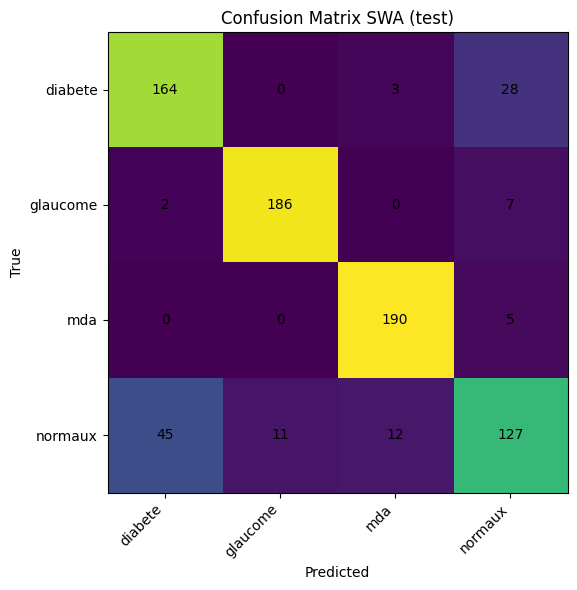

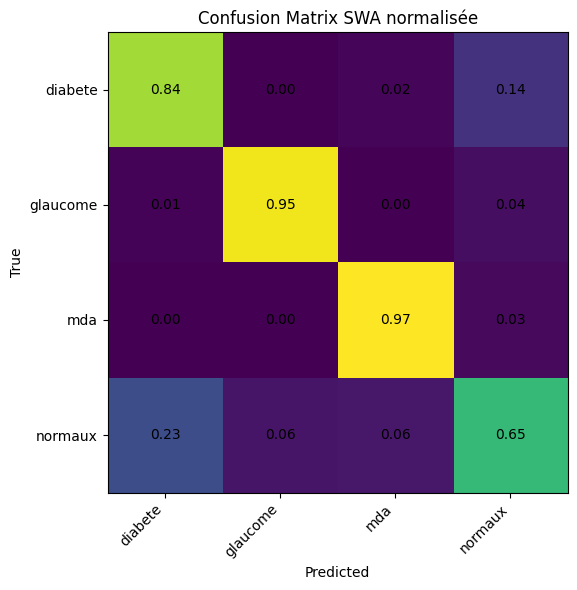


=== Classification report — ConvNeXt + SWA ===
              precision    recall  f1-score   support

     diabete     0.7773    0.8410    0.8079       195
    glaucome     0.9442    0.9538    0.9490       195
         mda     0.9268    0.9744    0.9500       195
     normaux     0.7605    0.6513    0.7017       195

    accuracy                         0.8551       780
   macro avg     0.8522    0.8551    0.8521       780
weighted avg     0.8522    0.8551    0.8521       780



In [8]:
# -------------------------
# 7) Évaluation sur le test set — comparaison normal vs SWA
# -------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Reconstruire swa_model si le kernel a été redémarré
if "swa_model" not in dir():
    _base = models.convnext_tiny(weights=None)
    _base.classifier[2] = nn.Linear(_base.classifier[2].in_features, num_classes)
    _base = _base.to(device)
    swa_model = AveragedModel(_base)
    swa_model.load_state_dict(torch.load("convnext_tiny_swa.pth", map_location=device, weights_only=True))

def predict_on_loader(m, loader):
    m.eval()
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            probs = torch.softmax(m(x), dim=1)
            y_pred.append(probs.argmax(1).cpu().numpy())
            y_true.append(y.numpy())
            y_proba.append(probs.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)
    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else str(cm[i,j]), ha="center", va="center")
    plt.tight_layout(); plt.show()

# Modèle SWA
y_true, y_pred, y_proba = predict_on_loader(swa_model, test_loader)
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix SWA (test)")
plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix SWA normalisée", normalize=True)

print("\n=== Classification report — ConvNeXt + SWA ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))
